In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.duplicated().sum()

np.int64(1)

In [4]:
df.shape

(1338, 7)

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
categorical_columns = ["sex", "smoker", "region"]

for column in categorical_columns:
    df[column] = (
        df[column]
        .str.strip()
        .str.lower()
    )

In [8]:
for column in categorical_columns:
    print(f"{column}: {df[column].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [9]:
numeric_columns = ["age", "bmi", "children", "charges"]

summary = df[numeric_columns].agg(
    ["count", "mean", "median", "std", "min", "max", "skew"]
).T

summary

,count,mean,median,std,min,max,skew
age,1337.0,39.222139,39.0000,14.044333,18.0000,64.00000,0.054781
bmi,1337.0,30.663452,30.4000,6.100468,15.9600,53.13000,0.283914
children,1337.0,1.095737,1.0000,1.205571,0.0000,5.00000,0.937421
charges,1337.0,13279.121487,9386.1613,12110.359656,1121.8739,63770.42801,1.515391


In [10]:
df[numeric_columns]

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1332,50,30.970,3,10600.54830
1333,18,31.920,0,2205.98080
1334,18,36.850,0,1629.83350
1335,21,25.800,0,2007.94500


In [11]:
for column in ["sex", "smoker", "region"]:
    print(f"\n{column.upper()}")
    print(df[column].value_counts())


SEX
sex
male      675
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1063
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [12]:
df[column].value_counts(normalize=True) * 100

,proportion
region,
southeast,27.225131
southwest,24.308153
northwest,24.233358
northeast,24.233358


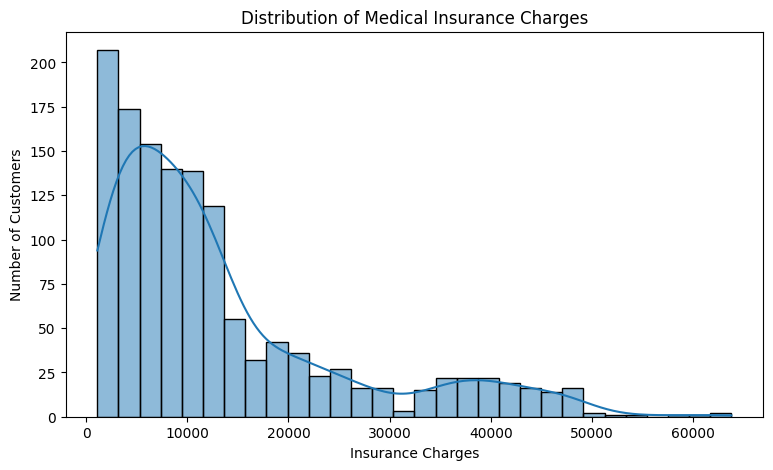

In [13]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
smoker_summary = (
    df.groupby("smoker")["charges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

smoker_summary

,count,mean,median,std,min,max
smoker,,,,,,
no,1063,8440.660307,7345.72660,5992.973800,1121.8739,36910.60803
yes,274,32050.231832,34456.34845,11541.547176,12829.4551,63770.42801


In [15]:
smokers = df.loc[df["smoker"] == "yes", "charges"]

non_smokers = df.loc[df["smoker"] == "no", "charges"]

In [16]:
from scipy.stats import levene

levene_stat, levene_p = levene(smokers, non_smokers)

print(f"Levene statistic: {levene_stat:.3f}")
print(f"p-value: {levene_p:.5f}")

Levene statistic: 332.471
p-value: 0.00000


In [17]:
from scipy import stats

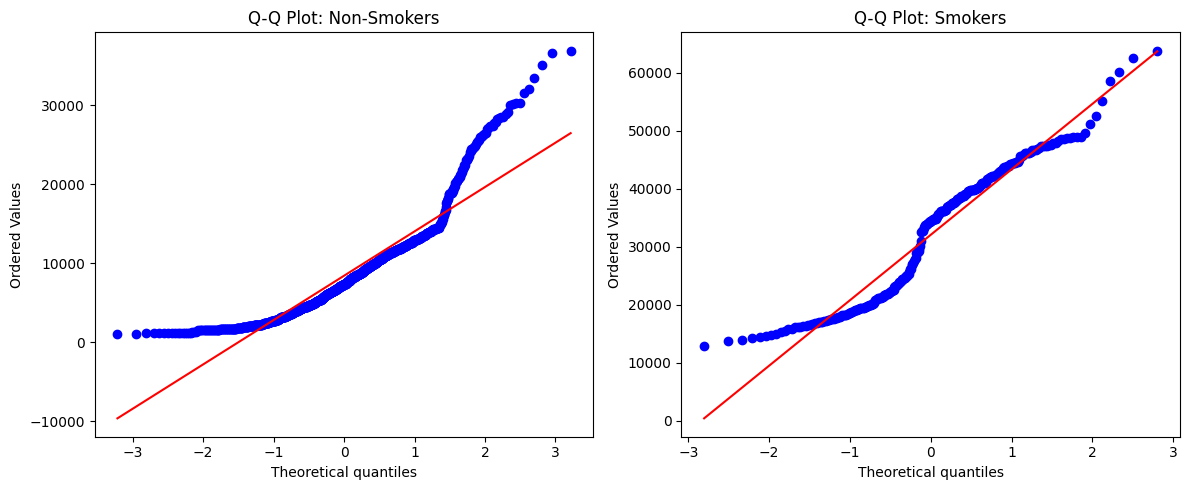

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(non_smokers, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Non-Smokers")

stats.probplot(smokers, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Smokers")

plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import shapiro

shapiro_smokers = shapiro(smokers)
shapiro_non_smokers = shapiro(non_smokers)

In [20]:
from scipy.stats import ttest_ind

t_stat, t_p = ttest_ind(
    smokers,
    non_smokers,
    equal_var=False
)

In [21]:
from scipy.stats import mannwhitneyu

u_stat, u_p = mannwhitneyu(
    smokers,
    non_smokers,
    alternative="two-sided"
)

In [23]:
mean_smokers = smokers.mean()
mean_non_smokers = non_smokers.mean()

std_smokers = smokers.std()
std_non_smokers = non_smokers.std()

n_smokers = len(smokers)
n_non_smokers = len(non_smokers)

In [24]:
pooled_std = (
    ((n_smokers - 1) * std_smokers**2 +
     (n_non_smokers - 1) * std_non_smokers**2)
    / (n_smokers + n_non_smokers - 2)
) ** 0.5

In [25]:
cohens_d = (
    mean_smokers - mean_non_smokers
) / pooled_std

cohens_d

np.float64(3.1602902766581233)

In [26]:
mean_diff = smokers.mean() - non_smokers.mean()

In [27]:
mean_diff = mean_smokers - mean_non_smokers

ci = stats.t.interval(
    0.95,
    df=n_smokers + n_non_smokers - 2,
    loc=mean_diff,
    scale=pooled_std * (1/n_smokers + 1/n_non_smokers)**0.5
)

mean_diff, ci

(np.float64(23609.571525023905),
 (np.float64(22616.622547926454), np.float64(24602.520502121355)))

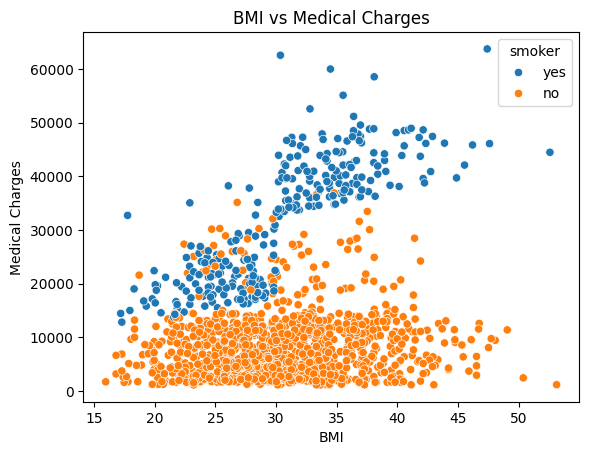

In [29]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.show()

In [30]:
pearson_r, pearson_p = stats.pearsonr(df["bmi"], df["charges"])
spearman_rho, spearman_p = stats.spearmanr(df["bmi"], df["charges"])

print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)
print("Spearman rho:", spearman_rho)
print("Spearman p-value:", spearman_p)

Pearson r: 0.19840083122624938
Pearson p-value: 2.4680404264513685e-13
Spearman rho: 0.11958495819244366
Spearman p-value: 1.1637179203181515e-05


In [31]:
smoker_df = df[df["smoker"] == "yes"]
non_smoker_df = df[df["smoker"] == "no"]

print("Smokers:", stats.pearsonr(smoker_df["bmi"], smoker_df["charges"]))
print("Non-smokers:", stats.pearsonr(non_smoker_df["bmi"], non_smoker_df["charges"]))

Smokers: PearsonRResult(statistic=np.float64(0.8064806070155405), pvalue=np.float64(5.0196686317951564e-64))
Non-smokers: PearsonRResult(statistic=np.float64(0.08407651699889863), pvalue=np.float64(0.006091103478055469))


In [32]:
print("Smokers:", stats.spearmanr(smoker_df["bmi"], smoker_df["charges"]))
print("Non-smokers:", stats.spearmanr(non_smoker_df["bmi"], non_smoker_df["charges"]))

Smokers: SignificanceResult(statistic=np.float64(0.8342278262089077), pvalue=np.float64(2.789393249174674e-72))
Non-smokers: SignificanceResult(statistic=np.float64(0.1053729790362056), pvalue=np.float64(0.0005793784869988553))


In [33]:
# 1. Calculate the mean charges for each region
df.groupby("region")["charges"].mean()

,charges
region,
northeast,13406.384516
northwest,12450.840844
southeast,14735.411438
southwest,12346.937377


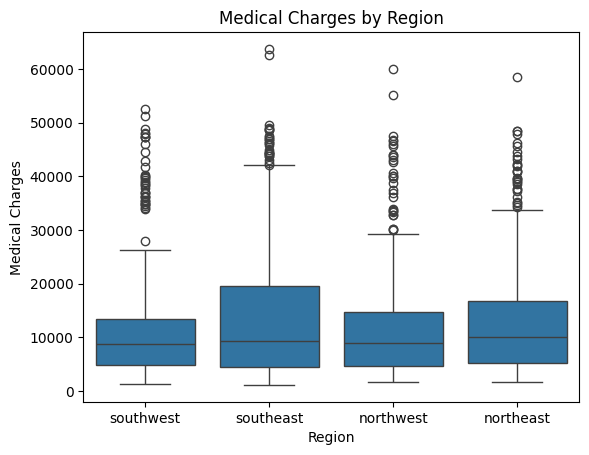

In [34]:
# 2. Compare the charge distributions across regions
sns.boxplot(data=df, x="region", y="charges")

plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Medical Charges")
plt.show()

In [35]:
# 3. Calculate the skewness of charges in each region
df.groupby("region")["charges"].skew()

,charges
region,
northeast,1.493360
northwest,1.680491
southeast,1.251265
southwest,1.682222


In [37]:
region_groups = [
    group["charges"].values
    for _, group in df.groupby("region")
]

stats.levene(*region_groups)

LeveneResult(statistic=np.float64(5.5534798606999125), pvalue=np.float64(0.0008689544824002284))

In [38]:
from statsmodels.stats.oneway import anova_oneway

welch_anova = anova_oneway(
    df["charges"],
    groups=df["region"],
    use_var="unequal"
)

welch_anova

<class 'statsmodels.stats.base.HolderTuple'>
statistic = np.float64(2.566222713601441)
pvalue = np.float64(0.05348899434656482)
df = (3.0, np.float64(740.4157504811701))
df_num = 3.0
df_denom = np.float64(740.4157504811701)
nobs_t = np.float64(1337.0)
n_groups = 4
means = array([13406.38451639, 12450.84084395, 14735.41143761, 12346.93737729])
nobs = array([324., 324., 364., 325.])
vars_ = array([1.26693103e+08, 1.22614113e+08, 1.95191596e+08, 1.33568389e+08])
use_var = 'unequal'
welch_correction = True
tuple = (np.float64(2.566222713601441), np.float64(0.05348899434656482))

In [39]:
region_data = [
    group["charges"].values
    for _, group in df.groupby("region")
]

stats.kruskal(*region_data)

KruskalResult(statistic=np.float64(4.622506584465555), pvalue=np.float64(0.20161983372303882))

In [40]:
contingency_table = pd.crosstab(df["region"], df["smoker"])

contingency_table

smoker,no,yes
region,,
northeast,257,67
northwest,266,58
southeast,273,91
southwest,267,58


In [41]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 7.27790254132191
p-value: 0.06354826573182334
Degrees of freedom: 3


In [42]:
n = contingency_table.to_numpy().sum()
phi2 = chi2 / n
r, k = contingency_table.shape

cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))

print("Cramér's V:", cramers_v)

Cramér's V: 0.07377978990310645


In [43]:
from itertools import combinations

regions = df["region"].unique()

for region1, region2 in combinations(regions, 2):
    group1 = df[df["region"] == region1]["charges"]
    group2 = df[df["region"] == region2]["charges"]

    stat, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"{region1} vs {region2}: U={stat:.2f}, p={p:.5f}")

southwest vs southeast: U=55887.00, p=0.21097
southwest vs northwest: U=51343.00, p=0.58434
southwest vs northeast: U=47681.00, p=0.03749
southeast vs northwest: U=60999.00, p=0.43522
southeast vs northeast: U=57489.00, p=0.56992
northwest vs northeast: U=48890.00, p=0.13109


In [44]:
from statsmodels.stats.multitest import multipletests

# Store the six pairwise p-values
pairwise_results = []

for region1, region2 in combinations(regions, 2):
    group1 = df[df["region"] == region1]["charges"]
    group2 = df[df["region"] == region2]["charges"]

    stat, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")
    pairwise_results.append((region1, region2, p))

p_values = [result[2] for result in pairwise_results]

bonferroni = multipletests(p_values, method="bonferroni")
holm = multipletests(p_values, method="holm")

for i, (region1, region2, raw_p) in enumerate(pairwise_results):
    print(
        f"{region1} vs {region2} | "
        f"Raw p={raw_p:.5f} | "
        f"Bonferroni p={bonferroni[1][i]:.5f} | "
        f"Holm p={holm[1][i]:.5f}"
    )

southwest vs southeast | Raw p=0.21097 | Bonferroni p=1.00000 | Holm p=0.84388
southwest vs northwest | Raw p=0.58434 | Bonferroni p=1.00000 | Holm p=1.00000
southwest vs northeast | Raw p=0.03749 | Bonferroni p=0.22494 | Holm p=0.22494
southeast vs northwest | Raw p=0.43522 | Bonferroni p=1.00000 | Holm p=1.00000
southeast vs northeast | Raw p=0.56992 | Bonferroni p=1.00000 | Holm p=1.00000
northwest vs northeast | Raw p=0.13109 | Bonferroni p=0.78654 | Holm p=0.65545


In [45]:
print("Bonferroni significant:", bonferroni[0])
print("Holm significant:", holm[0])

Bonferroni significant: [False False False False False False]
Holm significant: [False False False False False False]


In [49]:
final_results = {
    "Cohen's d": cohens_d,
    "Mean Difference": mean_diff,
    "95% CI": ci,
    "BMI Pearson r": pearson_r,
    "BMI Spearman rho": spearman_rho,
    "Regional Welch ANOVA p-value": welch_anova.pvalue,
    "Regional Kruskal-Wallis p-value": stats.kruskal(*region_data).pvalue,
    "Cramér's V": cramers_v
}

final_results

{"Cohen's d": np.float64(3.1602902766581233),
 'Mean Difference': np.float64(23609.571525023905),
 '95% CI': (np.float64(22616.622547926454), np.float64(24602.520502121355)),
 'BMI Pearson r': np.float64(0.19840083122624938),
 'BMI Spearman rho': np.float64(0.11958495819244366),
 'Regional Welch ANOVA p-value': np.float64(0.05348899434656482),
 'Regional Kruskal-Wallis p-value': np.float64(0.20161983372303882),
 "Cramér's V": np.float64(0.07377978990310645)}